In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Silence deepchem warnings if you have it installed
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_target = pd.read_csv(r'C:\Users\nandi\Documents\ML_CO2_ER\data\Data_computed_properties\filtered_ea.csv')
df_feat = pd.read_csv(r'C:\Users\nandi\Documents\ML_CO2_ER\data\df_rdkit_dft.csv')

In [3]:
'smiles' in df_target.columns
'smiles' in df_feat.columns

True

In [4]:
# Preprocess target df: ensure IDs match and targets are named correctly
df_target = df_target.rename(columns={'solvent ID': 'solvent_ID', 'EA_0-1': 'EA_values'})

# Merge features and targets on solvent_ID
df = pd.merge(df_feat, df_target[['solvent_ID', 'EA_values']], on='solvent_ID', how='inner')

In [5]:
df.drop("FractionCSP3", axis=1, inplace=True)

In [6]:
target_col = 'EA_values'
df_clean = df.dropna(subset=[target_col, 'smiles']).copy()
df_clean = df_clean.reset_index(drop=True)

In [7]:
df_clean = df_clean[df_clean['EA_values'] < -1.0]

In [8]:
df_clean['EA_values']

0      -4.403396
1      -5.536749
2      -5.795692
3      -5.454235
4      -4.429361
          ...   
3000   -4.848476
3001   -4.227101
3002   -3.924981
3003   -5.335819
3004   -4.139050
Name: EA_values, Length: 3002, dtype: float64

In [9]:
# Select numeric columns for features, excluding IDs and Targets
exclude_cols = ['smiles', 'solvent_ID', 'EA_values', 'scaffold', 'smiles_x', 'smiles_y']
X_cols = [c for c in df_clean.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_clean[c])]

X = df_clean[X_cols]
y = df_clean[target_col]
smiles = df_clean['smiles']

<Axes: >

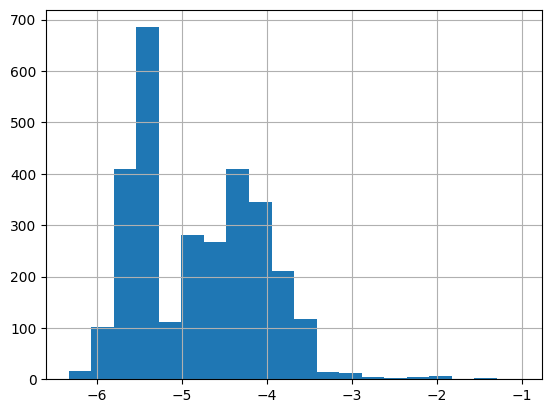

In [10]:
y.hist(bins=20)

In [11]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    tree_method='hist',  # key line for GPU
    device='cuda', 
    random_state=42
)

In [29]:


param_dist = {
    'model__iterations': [1000, 1500, 2000],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__depth': [6, 8, 10],
    'model__l2_leaf_reg': [1, 3, 5],
}

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('var_thresh', VarianceThreshold(threshold=0)),
    ('scaler', StandardScaler()),
    ('model', xgb) 
])

In [30]:
search_rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=5,
    verbose=1,
    n_jobs=1  # must be 1 when using GPU with XGBoost
)

In [31]:
from sklearn.model_selection import train_test_split
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# search_rand = RandomizedSearchCV(pipeline, param_dist, n_iter=20, cv=5, scoring='r2', n_jobs=1)

print("\n--- Tuning & Training ---")
search_rand.fit(X_train_rand, y_train_rand)

best_model_rand = search_rand.best_estimator_
y_pred_rand = best_model_rand.predict(X_test_rand)


--- Tuning & Training ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [33]:
stats_rand = (r2_score(y_test_rand, y_pred_rand), mean_absolute_error(y_test_rand, y_pred_rand))
stats_rand

(0.6471293683660824, 0.3132643843127722)

In [36]:
best_model_rand.get_params()

{'memory': None,
 'steps': [('imputer', SimpleImputer(strategy='median')),
  ('var_thresh', VarianceThreshold(threshold=0)),
  ('scaler', StandardScaler()),
  ('model',
   XGBRegressor(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, depth=6, device='cuda',
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, iterations=1500, l2_leaf_reg=1,
                learning_rate=0.03, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, ...))],
 'transform_input': None,
 'verbose': False,
 'imputer': S

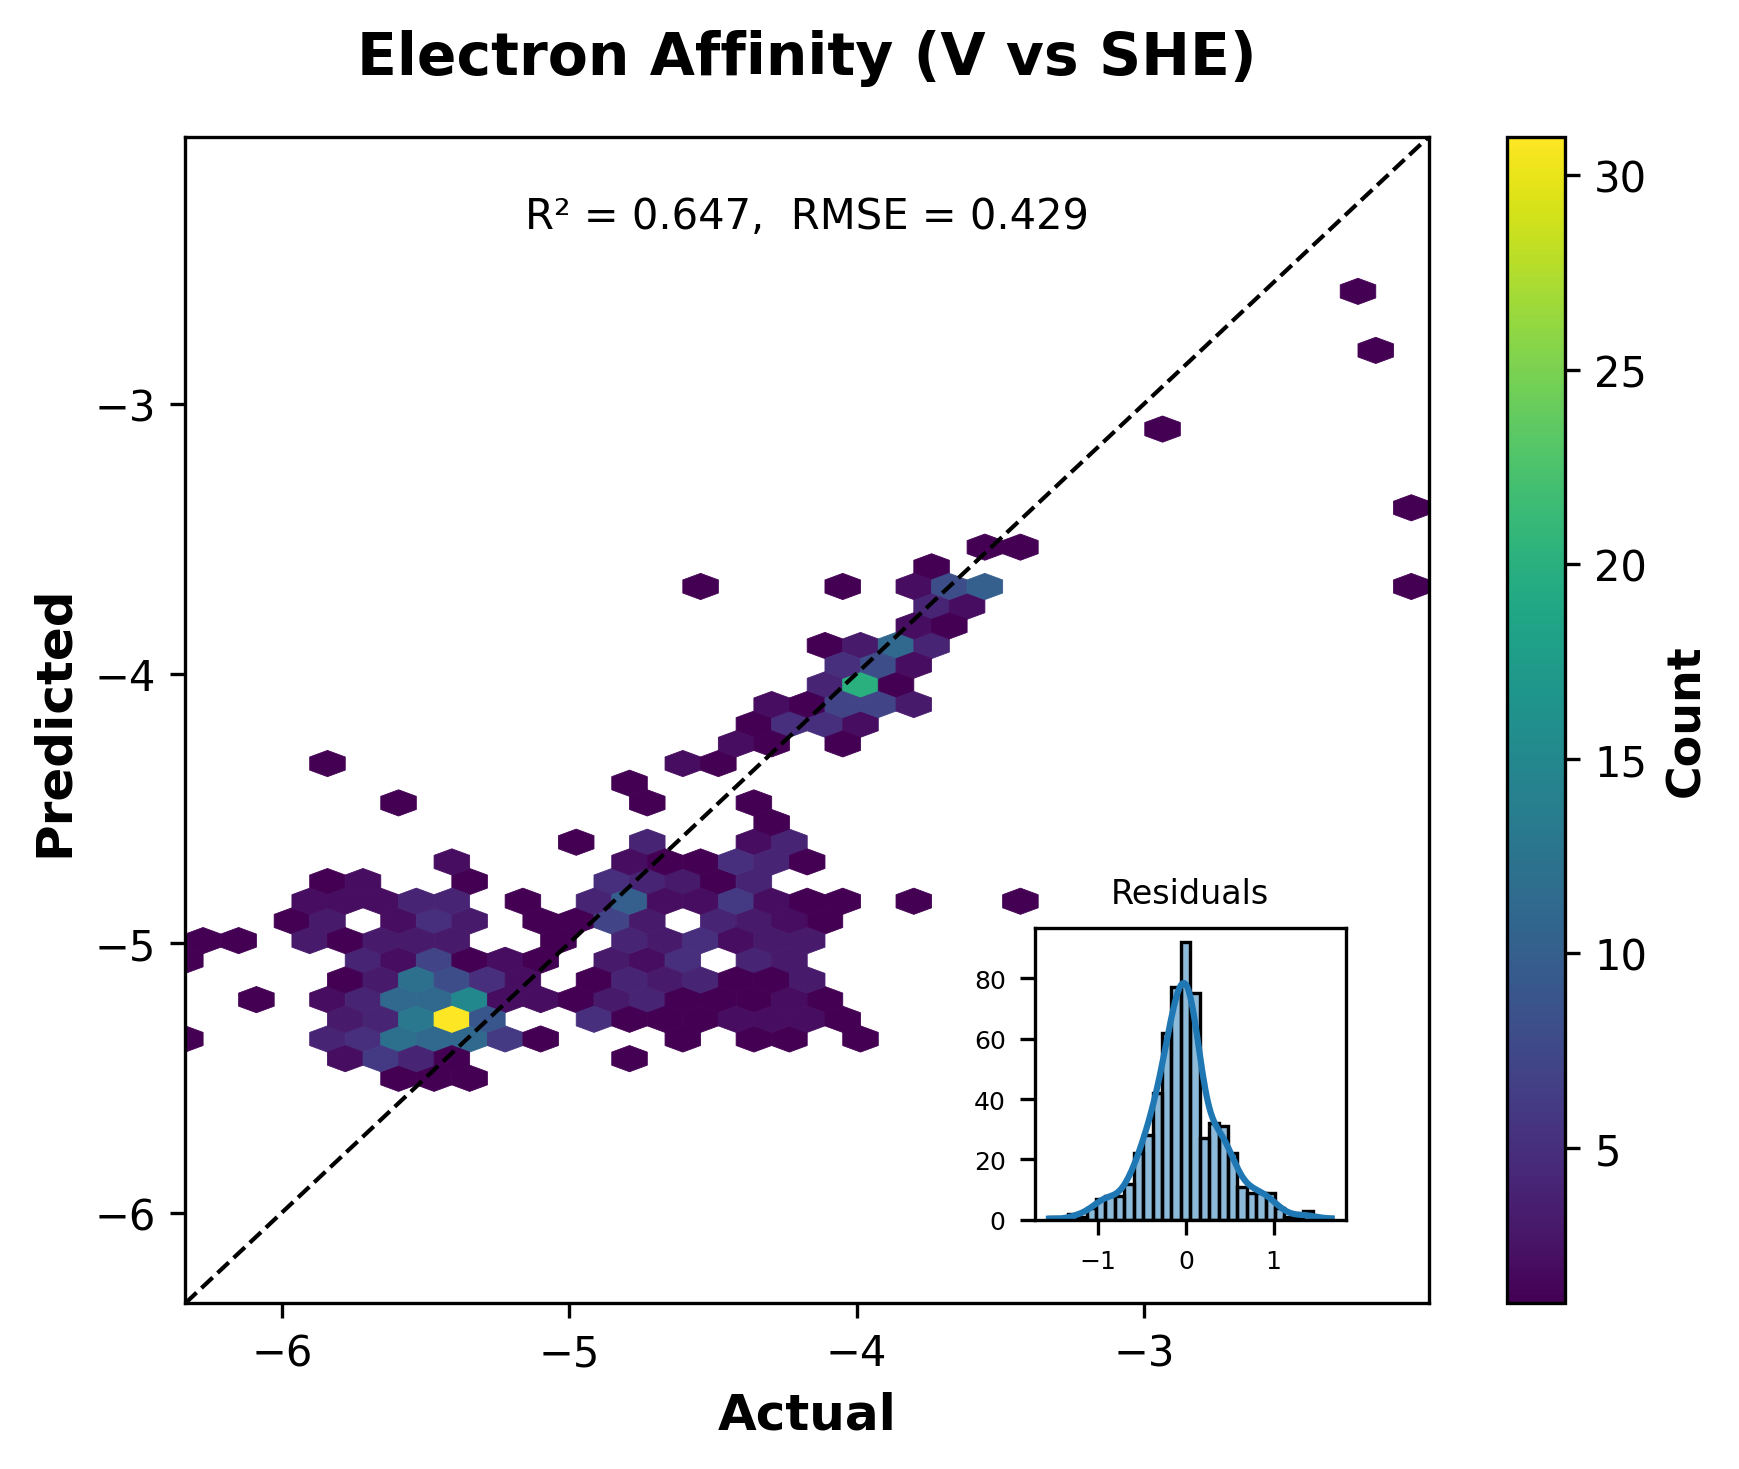

In [ ]:
from sklearn.metrics import mean_squared_error
rand_rmse = np.sqrt(mean_squared_error(y_test_rand, y_pred_rand))
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test_rand, y_pred_rand, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test_rand.min(), y_test_rand.max()], [y_test_rand.min(), y_test_rand.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([tick for tick in ax.get_xticks() if tick != 0])
ax.set_yticks([tick for tick in ax.get_yticks() if tick != 0])

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
ax.set_xlim(left=y_test_rand.min(), right=y_test_rand.max())
ax.set_ylim(bottom=y_test_rand.min(), top=y_test_rand.max())

x_center = (y_test_rand.min() + y_test_rand.max()) / 2

# Title and axes labels
ax.set_title(f"Electron Affinity (V vs SHE)", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {stats_rand[0]:.3f},  RMSE = {rand_rmse:.3f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
residuals = y_test_rand - y_pred_rand
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("EA_hexbin_density_plot_CB.png", dpi=300, bbox_inches='tight')
plt.show()

PermutationExplainer explainer: 602it [03:04,  3.18it/s]                         


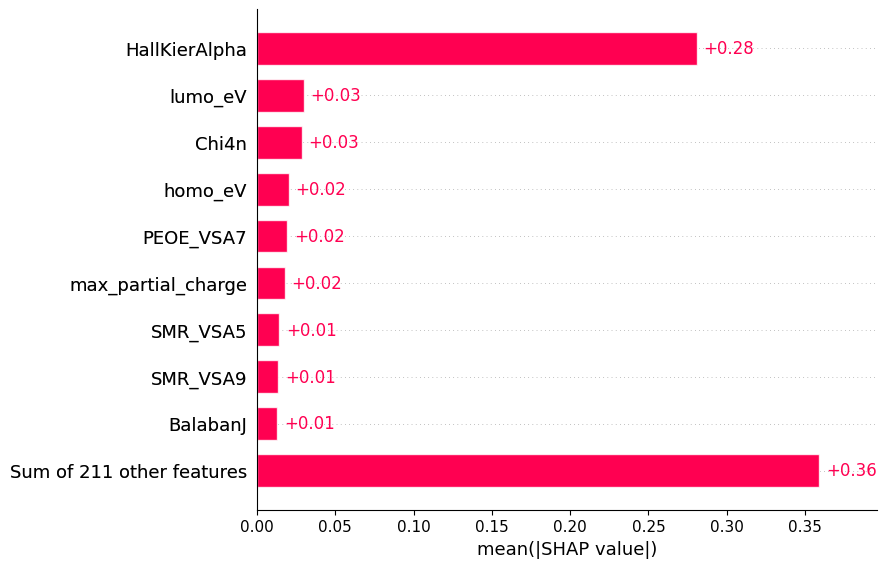

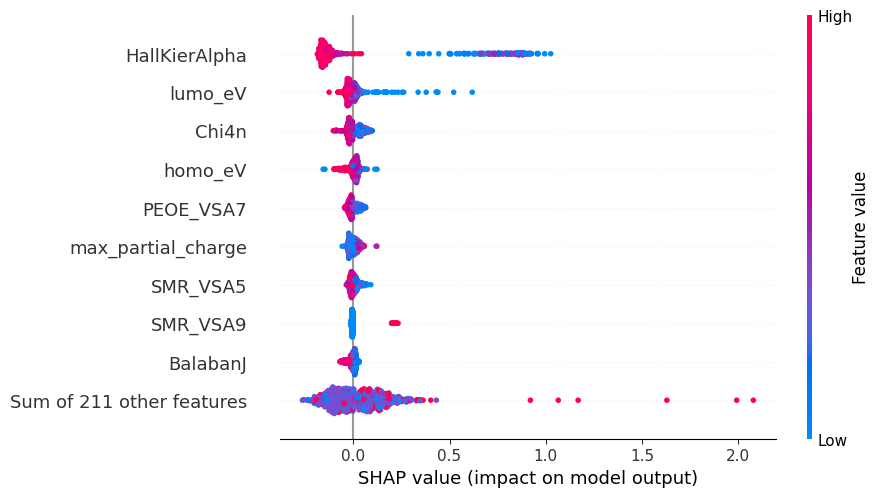

In [37]:
import shap

explainer_rand = shap.Explainer(best_model_rand.predict, X_test_rand, feature_names=X.columns)
shap_values_rand = explainer_rand(X_test_rand)

shap.plots.bar(shap_values_rand, max_display=10)
shap.plots.beeswarm(shap_values_rand, max_display=10)

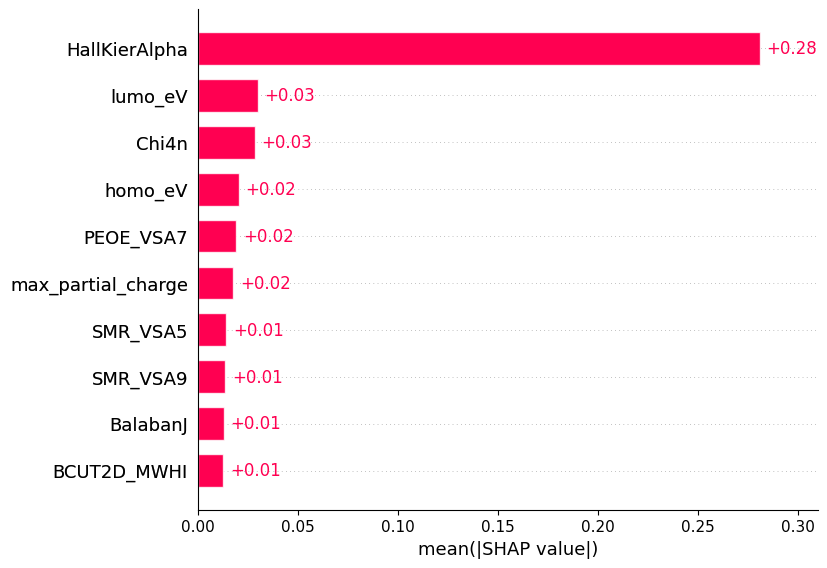

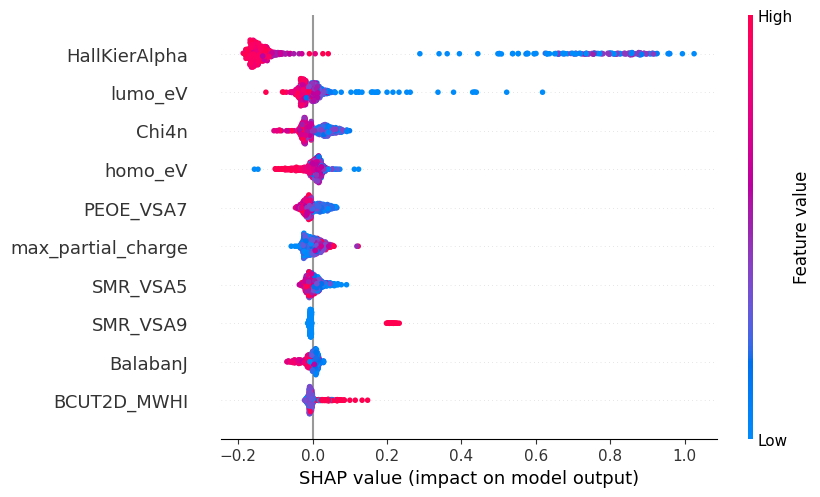

In [38]:
mean_shap_rand = np.abs(shap_values_rand.values).mean(axis=0)
top_10_indices_rand = np.argsort(mean_shap_rand)[-10:][::-1]

# Slice SHAP explanation to include only top 10 features
shap_values_top10_rand = shap.Explanation(
    values=shap_values_rand.values[:, top_10_indices_rand],
    base_values=shap_values_rand.base_values,
    data=shap_values_rand.data[:, top_10_indices_rand],
    feature_names=np.array(shap_values_rand.feature_names)[top_10_indices_rand].tolist()
)

# Plot only top 10 features
shap.plots.bar(shap_values_top10_rand)
shap.plots.beeswarm(shap_values_top10_rand)

In [39]:
import pandas as pd
import numpy as np

# 1. Get feature importance from SHAP
# Sum the absolute SHAP values for each feature to find the top ones
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values_rand.values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

# 2. Select the top 6 features (adjust this number if you want a more precise equation)
top_features = feature_importance['feature'].head(10).tolist()

print(f"Top features for equation: {top_features}")

Top features for equation: ['HallKierAlpha', 'lumo_eV', 'Chi4n', 'homo_eV', 'PEOE_VSA7', 'max_partial_charge', 'SMR_VSA5', 'SMR_VSA9', 'BalabanJ', 'BCUT2D_MWHI']


In [40]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Convert the scaled arrays back to DataFrames so we can use column names
# We use the original column names from 'X'
X_train_df = pd.DataFrame(X_train_rand, columns=X.columns)
X_test_df = pd.DataFrame(X_test_rand, columns=X.columns)

# 2. Now we can subset using the names you found
X_train_simple = X_train_df[top_features].dropna()
X_test_simple = X_test_df[top_features].dropna()

In [41]:
y_train_clean = y_train_rand.loc[X_train_simple.index]
y_test_clean = y_test_rand.loc[X_test_simple.index]

# 3. Fit the Simple Linear Model
linear_model = LinearRegression()
linear_model.fit(X_train_simple, y_train_clean)

# 4. Check accuracy
y_pred_linear = linear_model.predict(X_test_simple)
rmse_lin = np.sqrt(mean_squared_error(y_test_clean, y_pred_linear))
r2_lin = r2_score(y_test_clean, y_pred_linear)

print("--- Simple Linear Equation ---")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R² Score: {r2_lin:.4f}")
print("\nPredictive Equation:")
equation_terms = [f"({coef:.4f} * {name})" for name, coef in zip(top_features, linear_model.coef_)]
print(f"y = {linear_model.intercept_:.4f} + " + " + ".join(equation_terms))

--- Simple Linear Equation ---
RMSE: 0.5345
R² Score: 0.4523

Predictive Equation:
y = -4.4441 + (-1.5776 * HallKierAlpha) + (-0.0287 * lumo_eV) + (-0.3395 * Chi4n) + (0.0048 * homo_eV) + (0.0022 * PEOE_VSA7) + (-0.1887 * max_partial_charge) + (-0.0027 * SMR_VSA5) + (0.0748 * SMR_VSA9) + (-0.0440 * BalabanJ) + (0.0441 * BCUT2D_MWHI)
